# Python GIS Procedural Pipeline

This notebook implements an end-to-end pipeline:
1. Draw a polygon on an interactive map
2. Extract GeoJSON & transform coordinates to UTM (CCW ordering)
3. Generate a procedural building with PyPRT (CityEngine)
4. Visualize the 3D model with Three.js Viewer + Interactive Map

## تثبيت المكتبات (Install Libraries)

If running outside the project venv, uncomment the following line:
```
# !pip install leafmap shapely pyproj pyprt pythreejs ipywidgets trimesh
```

---
## الخلية 1: إعداد الخريطة ورسم المضلع
## Cell 1: Interactive Map & Polygon Drawing

In [1]:
# === Cell 1: Interactive Map & Polygon Drawing ===

import leafmap
from IPython.display import display

# Create interactive map centered on target area
m = leafmap.Map(center=[15.3694, 44.1910], zoom=16)

# Add drawing toolbar so the user can draw a polygon
# leafmap.Map comes with a drawing toolbar by default
# (No need to call add_draw_control() anymore)

print("✅ الخريطة جاهزة — ارسم مضلعًا ثم شغّل الخلية التالية")
print("✅ Map ready — draw a polygon then run Cell 2")

m

✅ الخريطة جاهزة — ارسم مضلعًا ثم شغّل الخلية التالية
✅ Map ready — draw a polygon then run Cell 2


Map(center=[15.3694, 44.191], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoo…

---
## الخلية 2: استخراج GeoJSON وتحويل الإحداثيات إلى UTM وترتيب CCW
## Cell 2: Extract GeoJSON → Transform to UTM → Ensure CCW Winding

إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):
[(44.183751, 15.366859), (44.183419, 15.366414), (44.184207, 15.365907), (44.184524, 15.366352), (44.183751, 15.366859)]

تم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح
(Coordinates transformed to UTM and ordered CCW successfully)

UTM Coords (5 vertices):
  [0] x=412395.97, y=1699068.25
  [1] x=412360.15, y=1699019.16
  [2] x=412444.52, y=1698962.76
  [3] x=412478.73, y=1699011.86
  [4] x=412395.97, y=1699068.25


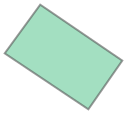

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [2]:
from shapely.geometry import shape, Polygon
from pyproj import Transformer

if len(m.draw_features) == 0:
    raise RuntimeError("لم يتم رسم أي مضلع بعد — No polygon drawn yet. Run Cell 1 and draw a polygon first.")

# Take the most recently drawn feature
geojson_feature = m.draw_features[-1]
polygon = shape(geojson_feature['geometry'])
coords = list(polygon.exterior.coords)

print("إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):")
print(coords)

# Transform from WGS84 (EPSG:4326) to UTM Zone 38N (EPSG:32638)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)
utm_coords = [transformer.transform(x, y) for x, y in coords]
utm_polygon = Polygon(utm_coords)

# Ensure counter-clockwise (CCW) winding order
if not utm_polygon.exterior.is_ccw:
    utm_coords = list(utm_polygon.exterior.coords)[::-1]
    utm_polygon = Polygon(utm_coords)

print("\nتم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح")
print("(Coordinates transformed to UTM and ordered CCW successfully)")
print(f"\nUTM Coords ({len(utm_coords)} vertices):")
for i, c in enumerate(utm_coords):
    print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")

from IPython.display import display
display(utm_polygon)  # Show the 2D polygon shape

# Create an interactive map for the extracted feature
m2 = leafmap.Map(center=[15, 45], zoom=16)
fc = {"type": "FeatureCollection", "features": [geojson_feature]}
m2.add_geojson(fc, layer_name="Extracted Polygon")
m2

---
## الخلية 3: إرسال الشكل إلى PyPRT وتوليد المبنى Procedural
## Cell 3: Send Shape to PyPRT & Generate Procedural Building

In [3]:
import pyprt, os, base64
import numpy as np

pyprt.initialize_prt()

# إخراج الإحداثيات للمبنى مع التوسيط (Centering) لضمان ظهوره في الفيوور
coords_2d = list(utm_polygon.exterior.coords)[:-1]

# حساب المركز (Centroid) لجعل الموديل حول نقطة الصفر (0,0,0)
center_x = sum(c[0] for c in coords_2d) / len(coords_2d)
center_y = sum(c[1] for c in coords_2d) / len(coords_2d)

flat_coords = []
for x, y in coords_2d:
    # طرح المركز لضمان التوسيط التام
    flat_coords.extend([x - center_x, 0.0, y - center_y])

initial_shape = pyprt.InitialShape(flat_coords)
attributes = {"Nbr_of_Floors": 12, "Usage": "Residential"}

RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
model_generator = pyprt.ModelGenerator([initial_shape])

encoder = "com.esri.prt.codecs.GLTFEncoder"
out_dir = os.path.join(os.getcwd(), "output_models")
os.makedirs(out_dir, exist_ok=True)

encoder_options = {
    "outputPath": out_dir,
    "baseName": "procedural_building"
}

# توليد المبنى
model_generator.generate_model([attributes], RPK_PATH, encoder, encoder_options)

# قراءة الملف وتحويله لـ Base64
glb_path = os.path.join(out_dir, "procedural_building_0.glb")
with open(glb_path, "rb") as f:
    glb_data = f.read()

model_b64 = base64.b64encode(glb_data).decode('utf-8')

print(f"✅ Model Centered and Ready!")
print(f"Shifted by Central Offset: X={center_x:.2f}, Y={center_y:.2f}")


[PRT] [2026-03-13 08:41:10] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Centered and Ready!
Shifted by Central Offset: X=412419.84, Y=1699015.51


---
## الخلية 4: عرض النموذج + خريطة تفاعلية + أدوات رسم
## Cell 4: 3D Viewer + Interactive Map + Drawing Tools

In [4]:
# === Cell 4: عرض النموذج ثلاثي الأبعاد بعارض Three.js الجديد ===
# === Cell 4: 3D Viewer (Three.js + Draco/Meshopt + Map) ===

import os, webbrowser
from IPython.display import display, HTML

# قراءة قالب العارض
template_path = os.path.join(os.getcwd(), 'viewer_template.html')
with open(template_path, 'r', encoding='utf-8') as f:
    html_content = f.read()

# استبدال البيانات
final_html = html_content.replace('%%MODEL_B64%%', model_b64)

# حفظ وفتح
html_filename = 'viewer_full.html'
with open(html_filename, 'w', encoding='utf-8') as f:
    f.write(final_html)

full_path = os.path.abspath(html_filename)
webbrowser.open('file:///' + full_path.replace(chr(92), '/'))

display(HTML("""
<div style='border: 2px solid #6366f1; background: linear-gradient(135deg, #eef2ff, #e0e7ff); padding: 25px; border-radius: 12px; font-family: system-ui; text-align: center;'>
    <h2 style='color: #4f46e5; margin-top: 0;'>🎉 العارض الجديد جاهز!</h2>
    <p style='color: #333;'>Three.js Viewer مع دعم Draco/Meshopt + خريطة تفاعلية</p>
    <div style='display: flex; gap: 10px; justify-content: center; flex-wrap: wrap; margin: 15px 0;'>
        <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>🔧 Draco Compression</span>
        <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>📦 Meshopt Decoder</span>
        <span style='background: #dbeafe; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>▶ Animation Playback</span>
        <span style='background: #fef3c7; padding: 6px 12px; border-radius: 20px; font-size: 12px;'>🗺 خريطة تفاعلية</span>
    </div>
    <a href='viewer_full.html' target='_blank' 
       style='background: linear-gradient(135deg, #6366f1, #4f46e5); color: white; padding: 14px 28px; text-decoration: none; border-radius: 8px; font-weight: bold; display: inline-block; box-shadow: 0 4px 16px rgba(99,102,241,0.35);'>
       🏗 فتح العارض
    </a>
</div>
"""))
